### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [14]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [15]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [16]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [17]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [18]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [19]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [20]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

tavily.invoke("Provide me the recent AI news for 6th May 2026")

[{'title': 'State of AI: May 2026',
  'url': 'https://press.airstreet.com/p/state-of-ai-may-2026',
  'content': 'Coding, agents, and enterprise AI. Cognition was reported in talks for a follow-on at $25B, more than doubling the September 2025 mark of $10.2B. Cursor was reported in talks to raise $2B+ at $50B+ as enterprise revenue surged toward a $6B run-rate exit. Avoca hit unicorn status with $125M across three rounds at $1B for HVAC, plumbing, and roofing service agents (Series B led by Meritech and General Catalyst, Series A by Kleiner Perkins).\n\nDefense. Saronic raised $1.75B at $9.25B for autonomous naval vessels under the DoD’s Replicator initiative, more than doubling its mark from a year earlier.\n\nHealthcare AI. Qualified Health raised $125M for generative AI inside health-system clinical and operational workflows. [...] OpenAI’s GPT-5.5 followed just three weeks later with a near-identical capability profile: 2 of 10 end-to-end solves and 71.4% on expert tasks, carrying t

In [21]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [22]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

llm_with_tools=llm.bind_tools(tools)

In [23]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News". They want recent AI news. We should provide up-to-date AI news. We might need to browse the web. Use tavily_search_results_json to get recent AI news. Let\'s search.', 'tool_calls': [{'id': 'fc_405a9542-127c-4c26-970e-6d68e6269938', 'function': {'arguments': '{"query":"recent AI news 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 291, 'total_tokens': 374, 'completion_time': 0.084705288, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.015449353, 'prompt_tokens_details': None, 'queue_time': 0.154583856, 'total_time': 0.100154641}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbce-f143-7313-95e2-120cfb9c7920-0',

In [24]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

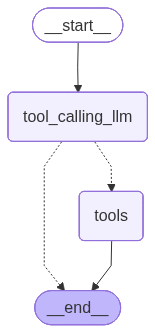

In [27]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [28]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_79228f26-d139-4f2d-99ee-03216f2979e3)
 Call ID: fc_79228f26-d139-4f2d-99ee-03216f2979e3
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [29]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for 6th May 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for 6th May 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_d7be0915-2fb6-4ad3-82a9-5671f37b332e)
 Call ID: fc_d7be0915-2fb6-4ad3-82a9-5671f37b332e
  Args:
    query: AI news 6 May 2025 top 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Emerging AI News Roundup for May and June 2025 Part 1: AI Agents, Jobs Impact, and the Return of the Surge", "url": "https://www.ptechpartners.com/2025/07/01/emerging-ai-news-roundup-for-may-and-june-2025-part-1-ai-agents-jobs-impact-and-the-return-of-the-surge/", "content": "### AI Innovations in Supply Chain\n\n   The use of AI in supply chain systems is already helping to lower logistics costs, with better demand forecasting and inventory maintenance, and Amazon in June 

In [31]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning according to wikipedia?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning according to wikipedia?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fc_8a573382-1a5d-42ea-b347-ad014d360b55)
 Call ID: fc_8a573382-1a5d-42ea-b347-ad014d360b55
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me
